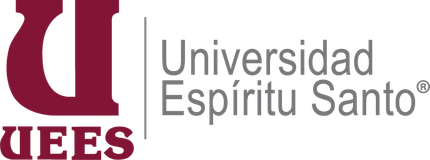

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 2 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E2.3 · SVM, kernels y k vecinos (KNN)</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Entender el margen, los vectores de soporte y el truco del kernel; entender cómo decide KNN y por qué depende de la distancia; y ajustar hiperparámetros sin fuga en un problema de seguridad informática. |
| **Resultado de aprendizaje** | RDA1 · competencias CG-G1 y CE-G1 |
| **Duración** | ≈ 4 h |
| **Teoría** | Manual M2 §5–§6 · Animaciones A2.5 y A2.11 · Video V2.2 |
| **Datos** | Sintéticos (`make_moons`, `make_circles`) · **PhishingWebsites** (OpenML 4534: 11 055 sitios web, 30 indicadores de la URL y la página, 44 % de phishing) |

**Niveles:** 1 · SVM lineal por subgradiente y KNN desde cero → 2 · `SVC` lineal y RBF, malla C × gamma; `KNeighborsClassifier`, k y escalado → 3 · detección de phishing con SVM y KNN → 4 · reto: costo computacional al crecer n (entrenar y predecir).

## 0 · Configuración

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
print(f"scikit-learn {sklearn.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · semilla 2026


## Nivel 1 · Desde cero (prelaboratorio)

La SVM lineal minimiza la **pérdida hinge** con penalización L2:

$$J(w, b) = \frac{\lambda}{2}\|w\|^2 + \frac1n\sum_i \max\big(0,\ 1 - y_i(w^\top x_i + b)\big), \qquad y_i \in \{-1, +1\}$$

La hinge no es derivable en 1, así que usamos un **subgradiente**: los puntos con $y_i f(x_i) < 1$ (dentro del margen o mal clasificados) empujan; los demás no aportan nada. Esa es la razón por la que solo los vectores de soporte definen la frontera.

In [2]:
from sklearn.datasets import make_blobs

Xl, yl01 = make_blobs(n_samples=120, centers=[[-1.5, -1.0], [1.5, 1.2]], cluster_std=1.0, random_state=SEED)
yl = np.where(yl01 == 1, 1, -1)


def svm_subgradiente(X, y, lam=0.01, iters=4000, eta0=1.0):
    """SVM lineal por subgradiente con tasa decreciente eta0 / (1 + lam·eta0·t). Devuelve (w, b, historial de J)."""
    n, p = X.shape
    w, b, hist = np.zeros(p), 0.0, []
    for t in range(iters):
        eta = eta0 / (1 + lam * eta0 * t)
        # TODO: calcula los márgenes y f(x), el conjunto activo (margen < 1) y el subgradiente de J; actualiza w y b.
        margen = y * (X @ w + b)
        activo = margen < 1
        gw = lam * w - (y[activo, None] * X[activo]).sum(axis=0) / n
        gb = -y[activo].sum() / n
        w, b = w - eta * gw, b - eta * gb
        hist.append(lam / 2 * w @ w + np.maximum(0, 1 - margen).mean())
    return w, b, np.array(hist)


w_s, b_s, hist_s = svm_subgradiente(Xl, yl)
f_s = Xl @ w_s + b_s
soportes = np.abs(yl * f_s) <= 1.05
print(f"w = {np.round(w_s, 3)} · b = {b_s:.3f} · ancho del margen 2/‖w‖ = {2 / np.linalg.norm(w_s):.3f}")
print(f"puntos en el margen o dentro de él: {int(np.sum(yl * f_s <= 1.05))} de {len(yl)}")

w = [1.505 0.792] · b = -0.368 · ancho del margen 2/‖w‖ = 1.176
puntos en el margen o dentro de él: 12 de 120


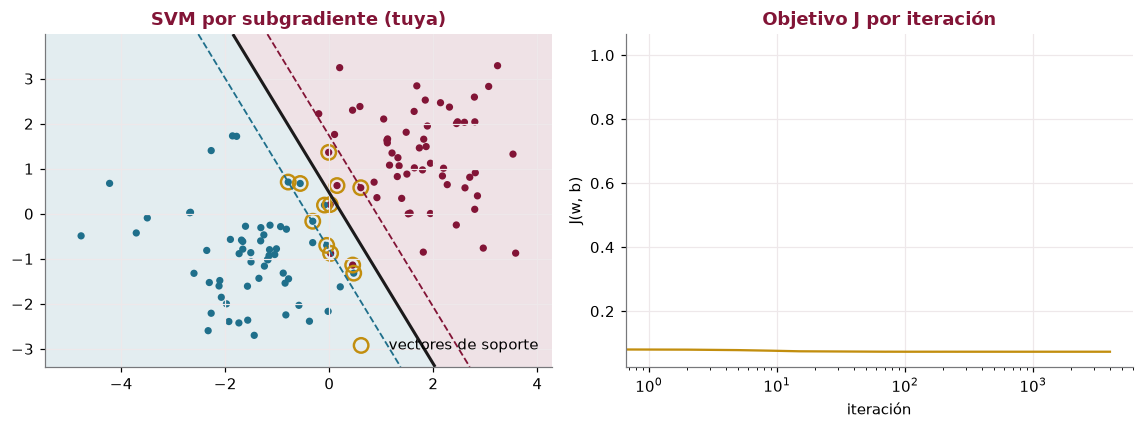

In [3]:
def dibujar_svm(ax, X, y, decision, titulo, sv=None):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.7, X[:, 0].max() + 0.7, 250), np.linspace(X[:, 1].min() - 0.7, X[:, 1].max() + 0.7, 250))
    Z = decision(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-100, 0, 100], colors=[UEES["azul"], UEES["vino"]], alpha=0.12)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=[UEES["azul"], "#1C1A1B", UEES["vino"]], linestyles=["--", "-", "--"], linewidths=[1.2, 2, 1.2])
    ax.scatter(X[:, 0], X[:, 1], c=np.where(y > 0, UEES["vino"], UEES["azul"]), s=14)
    if sv is not None:
        ax.scatter(X[sv, 0], X[sv, 1], s=90, facecolors="none", edgecolors=UEES["ocre"], linewidths=1.6, label="vectores de soporte")
        ax.legend(loc="lower right")
    ax.set(title=titulo)


fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
dibujar_svm(axes[0], Xl, yl, lambda P: P @ w_s + b_s, "SVM por subgradiente (tuya)", sv=soportes)
axes[1].plot(hist_s, color=UEES["ocre"])
axes[1].set(title="Objetivo J por iteración", xlabel="iteración", ylabel="J(w, b)", xscale="log")
plt.tight_layout()
plt.show()

### 1.2 KNN desde cero
KNN no ajusta parámetros: para cada punto nuevo calcula su distancia a **todos** los de entrenamiento, toma los $k$ más cercanos $N_k(x)$ y los deja votar. La proporción de votos de la clase 1 es su probabilidad estimada:

$$\hat p(1 \mid x) = \frac1k \sum_{i \in N_k(x)} \mathbb 1[y_i = 1]$$

In [4]:
from sklearn.datasets import make_moons

Xk, yk = make_moons(n_samples=600, noise=0.3, random_state=SEED)
Xk_tr, Xk_va, yk_tr, yk_va = Xk[:400], Xk[400:], yk[:400], yk[400:]      # make_moons ya viene barajado


def knn_proba(X_tr, y_tr, X, k):
    """Proporción de vecinos de clase 1 entre los k más cercanos (distancia euclidiana) de cada fila de X."""
    # TODO: matriz de distancias (consultas × entrenamiento) con broadcasting, índices de los k menores y
    # promedio de las etiquetas de esos vecinos.
    dist = np.sqrt(((X[:, None, :] - X_tr[None, :, :]) ** 2).sum(axis=2))
    vecinos = np.argsort(dist, axis=1, kind="stable")[:, :k]
    return y_tr[vecinos].mean(axis=1)


for k in (1, 15, 101):
    acc_tr = np.mean((knn_proba(Xk_tr, yk_tr, Xk_tr, k) > 0.5) == yk_tr)
    acc_va = np.mean((knn_proba(Xk_tr, yk_tr, Xk_va, k) > 0.5) == yk_va)
    print(f"k = {k:3d} · exactitud de entrenamiento {acc_tr:.3f} · de validación {acc_va:.3f}")

k =   1 · exactitud de entrenamiento 1.000 · de validación 0.850
k =  15 · exactitud de entrenamiento 0.902 · de validación 0.905
k = 101 · exactitud de entrenamiento 0.905 · de validación 0.895


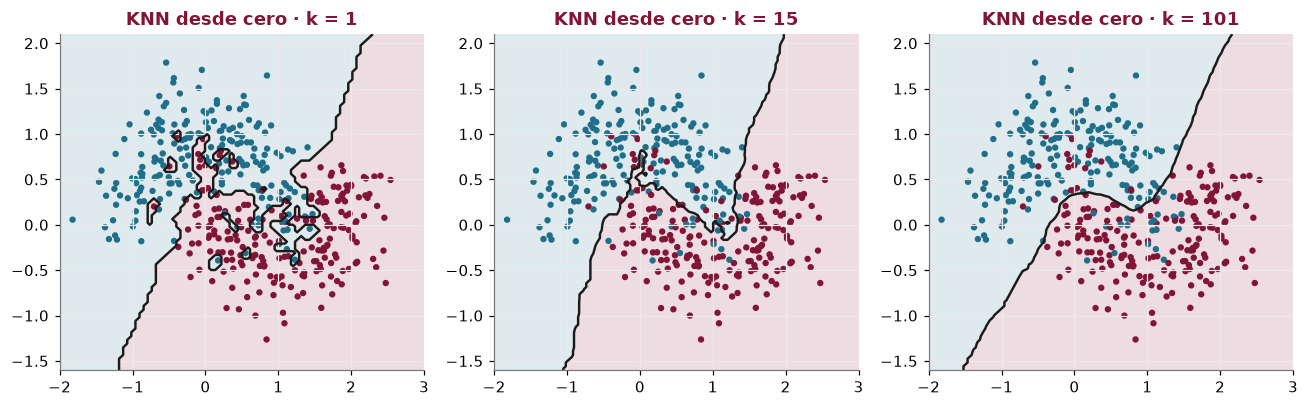

In [5]:
xx_k, yy_k = np.meshgrid(np.linspace(-2, 3, 90), np.linspace(-1.6, 2.1, 90))
malla_k = np.c_[xx_k.ravel(), yy_k.ravel()]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, k in zip(axes, (1, 15, 101)):
    P = knn_proba(Xk_tr, yk_tr, malla_k, k).reshape(xx_k.shape)
    ax.contourf(xx_k, yy_k, P, levels=[0, 0.5, 1], colors=[UEES["azul"], UEES["vino"]], alpha=0.14)
    ax.contour(xx_k, yy_k, P, levels=[0.5], colors="#1C1A1B", linewidths=1.6)
    ax.scatter(Xk_tr[:, 0], Xk_tr[:, 1], c=np.where(yk_tr == 1, UEES["vino"], UEES["azul"]), s=10)
    ax.set(title=f"KNN desde cero · k = {k}")
plt.tight_layout()
plt.show()

**Qué observar.** Con k = 1 cada punto de entrenamiento es su propio vecino: exactitud de entrenamiento 1.000 y de validación 0.850, con islas alrededor de los puntos ruidosos. Con k = 15 la frontera se suaviza y la validación sube a 0.905. Con k = 101 la frontera se aplana y empieza a perder la forma de las lunas (0.895). k controla el compromiso sesgo–varianza.

## Nivel 2 · Con scikit-learn
`SVC(kernel="linear", C=C)` resuelve el mismo problema de forma exacta. La relación entre ambos es $C = 1/(\lambda n)$.

In [6]:
from sklearn.svm import SVC

svc_lin = SVC(kernel="linear", C=1 / (0.01 * len(yl))).fit(Xl, yl)
w_sk, b_sk = svc_lin.coef_[0], svc_lin.intercept_[0]
coseno = w_s @ w_sk / (np.linalg.norm(w_s) * np.linalg.norm(w_sk))
print(f"scikit-learn: w = {np.round(w_sk, 3)} · b = {b_sk:.3f} · {len(svc_lin.support_)} vectores de soporte")
print(f"coseno entre tu w y el de scikit-learn: {coseno:.4f} · coincidencia de predicciones: {np.mean(np.sign(f_s) == svc_lin.predict(Xl)):.3f}")
assert coseno > 0.99, "Tu SVM no apunta en la misma dirección que la de scikit-learn."
print("✓ Tu SVM coincide con scikit-learn")

scikit-learn: w = [1.505 0.793] · b = -0.368 · 12 vectores de soporte
coseno entre tu w y el de scikit-learn: 1.0000 · coincidencia de predicciones: 1.000
✓ Tu SVM coincide con scikit-learn


### 2.1 Cuando una recta no alcanza: kernels
En `make_moons` y `make_circles` ninguna recta separa bien. El kernel RBF, $K(x, x') = e^{-\gamma\|x - x'\|^2}$, permite fronteras curvas.

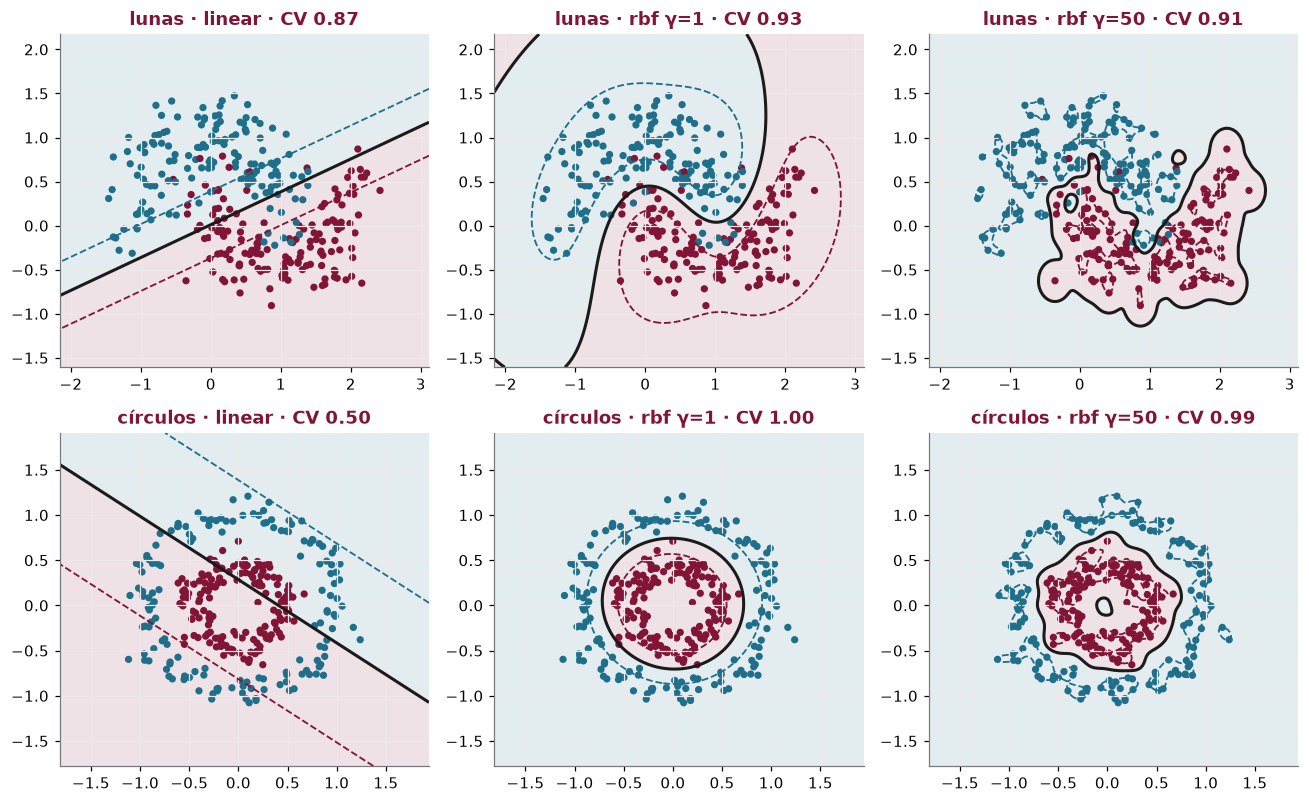

In [7]:
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Xm, ym = make_moons(n_samples=300, noise=0.25, random_state=SEED)
Xci, yci = make_circles(n_samples=300, noise=0.1, factor=0.45, random_state=SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(12, 7.4))
for fila, (X_, y_, nombre) in enumerate([(Xm, ym, "lunas"), (Xci, yci, "círculos")]):
    for col, (kern, g) in enumerate([("linear", "scale"), ("rbf", 1), ("rbf", 50)]):
        m = SVC(kernel=kern, C=1, gamma=g).fit(X_, y_)
        acc = cross_val_score(SVC(kernel=kern, C=1, gamma=g), X_, y_, cv=cv).mean()
        dibujar_svm(axes[fila, col], X_, np.where(y_ == 1, 1, -1), m.decision_function,
                    f"{nombre} · {kern}{'' if kern == 'linear' else f' γ={g}'} · CV {acc:.2f}")
plt.tight_layout()
plt.show()

**Qué observar.** El kernel lineal fracasa en ambos; RBF con γ = 1 sigue la forma; γ = 50 dibuja islas alrededor de los puntos (sobreajuste). Ahora buscamos C y γ en una malla con validación cruzada.

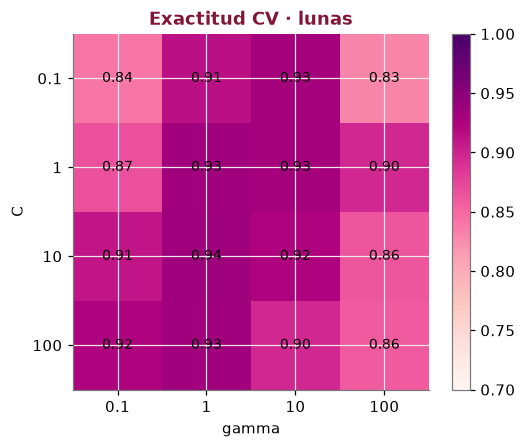

mejor combinación en lunas: C = 10, gamma = 1 · CV 0.937


In [8]:
Cs, gammas = [0.1, 1, 10, 100], [0.1, 1, 10, 100]
malla = np.array([[cross_val_score(SVC(C=C, gamma=g), Xm, ym, cv=cv).mean() for g in gammas] for C in Cs])
fig, ax = plt.subplots(figsize=(5.4, 4.2))
im = ax.imshow(malla, cmap="RdPu", vmin=0.7, vmax=1)
ax.set(xticks=range(4), xticklabels=gammas, yticks=range(4), yticklabels=Cs, xlabel="gamma", ylabel="C", title="Exactitud CV · lunas")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{malla[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax)
plt.show()
i_best, j_best = np.unravel_index(malla.argmax(), malla.shape)
print(f"mejor combinación en lunas: C = {Cs[i_best]}, gamma = {gammas[j_best]} · CV {malla.max():.3f}")

### 2.2 KNN con scikit-learn: k, escalado y pesos
`KNeighborsClassifier` hace la misma búsqueda exhaustiva que tu función (con `algorithm="brute"`). Primero comprobamos que coinciden.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_sk = KNeighborsClassifier(n_neighbors=15, algorithm="brute").fit(Xk_tr, yk_tr)
coinciden = np.mean(knn_sk.predict(Xk_va) == (knn_proba(Xk_tr, yk_tr, Xk_va, 15) > 0.5))
print(f"coincidencia de predicciones con tu KNN (k = 15): {coinciden:.3f}")
assert coinciden == 1.0, "Tu KNN no coincide con el de scikit-learn."
print("✓ Tu KNN coincide con scikit-learn")

coincidencia de predicciones con tu KNN (k = 15): 1.000
✓ Tu KNN coincide con scikit-learn


**k es un hiperparámetro** y se elige por validación cruzada: con k pequeño el modelo memoriza; con k grande promedia vecindarios enormes.

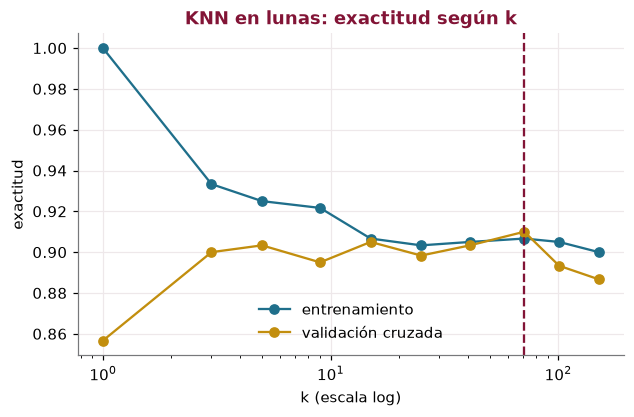

mejor k por validación cruzada: 71 · exactitud CV 0.910 · con k = 1: 0.857 · con k = 151: 0.887


In [10]:
ks = [1, 3, 5, 9, 15, 25, 41, 71, 101, 151]
cv_k = [cross_val_score(KNeighborsClassifier(n_neighbors=k), Xk, yk, cv=cv).mean() for k in ks]
tr_k = [KNeighborsClassifier(n_neighbors=k).fit(Xk, yk).score(Xk, yk) for k in ks]
k_mejor = ks[int(np.argmax(cv_k))]
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(ks, tr_k, "o-", color=UEES["azul"], label="entrenamiento")
ax.plot(ks, cv_k, "o-", color=UEES["ocre"], label="validación cruzada")
ax.axvline(k_mejor, ls="--", color=UEES["vino"])
ax.set(xscale="log", xlabel="k (escala log)", ylabel="exactitud", title="KNN en lunas: exactitud según k")
ax.legend()
plt.show()
print(f"mejor k por validación cruzada: {k_mejor} · exactitud CV {max(cv_k):.3f} · con k = 1: {cv_k[0]:.3f} · con k = 151: {cv_k[-1]:.3f}")

**Escalar no es opcional.** Mismos datos, pero la segunda variable registrada en otra unidad (× 100, como pasar de metros a centímetros). Sin escalar, esa variable domina la distancia.

In [11]:
Xk_unidad = Xk * np.array([1, 100])
acc_unidad_sin = cross_val_score(KNeighborsClassifier(n_neighbors=k_mejor), Xk_unidad, yk, cv=cv).mean()
acc_unidad_escalada = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_mejor)), Xk_unidad, yk, cv=cv).mean()
print(f"segunda variable × 100 · sin escalar: exactitud CV {acc_unidad_sin:.3f} · con StandardScaler: {acc_unidad_escalada:.3f}")

segunda variable × 100 · sin escalar: exactitud CV 0.792 · con StandardScaler: 0.895


In [12]:
for w in ("uniform", "distance"):
    m = KNeighborsClassifier(n_neighbors=k_mejor, weights=w)
    print(f"weights={w:8s} · exactitud de entrenamiento {m.fit(Xk, yk).score(Xk, yk):.3f} · CV {cross_val_score(m, Xk, yk, cv=cv).mean():.3f}")

weights=uniform  · exactitud de entrenamiento 0.907 · CV 0.910
weights=distance · exactitud de entrenamiento 1.000 · CV 0.902


**Qué observar.** Tu KNN y el de scikit-learn coinciden en todas las predicciones. Por validación cruzada, k = 1 da 0.857 y el mejor k es 71 (0.910), aunque la curva es casi plana entre 3 y 100: cualquier k de esa zona es razonable. Si la segunda variable se registra en otra unidad (× 100), la exactitud cae a 0.792 sin escalar y vuelve a 0.895 con `StandardScaler` dentro del pipeline. Con `weights="distance"` la exactitud de entrenamiento es 1.000 (cada punto es su propio vecino, a distancia 0), así que deja de servir para diagnosticar sobreajuste; en validación cruzada da 0.902, parecido a los pesos uniformes.

## Nivel 3 · Datos reales: detección de phishing

Cada fila es un sitio web descrito por 30 indicadores ya codificados en −1, 0 y 1 (¿la URL usa una IP?, ¿tiene certificado SSL válido?, ¿el dominio es nuevo?…). El objetivo indica si el sitio es phishing.

In [13]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split

phish = fetch_openml(data_id=4534, as_frame=True)
Xp = phish.data.astype(int)
yp = (phish.target == "-1").astype(int)          # en este dataset, −1 = phishing
print(f"{len(Xp)} sitios · {Xp.shape[1]} indicadores · {yp.mean():.1%} phishing")
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(Xp, yp, test_size=0.25, stratify=yp, random_state=SEED)

11055 sitios · 30 indicadores · 44.3% phishing


Buscamos C y γ con `GridSearchCV` **dentro del conjunto de entrenamiento** (la prueba no se toca). Para que la búsqueda sea rápida usamos una submuestra estratificada de 3000 sitios; el modelo final se reentrena con todo el entrenamiento.

In [14]:
Xp_sub, _, yp_sub, _ = train_test_split(Xp_tr, yp_tr, train_size=3000, stratify=yp_tr, random_state=SEED)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
busqueda = GridSearchCV(make_pipeline(StandardScaler(), SVC()),
                        {"svc__C": [0.3, 3, 30], "svc__gamma": [0.003, 0.03, 0.3]}, cv=cv3, scoring="f1", n_jobs=-1)
t0 = time.perf_counter()
busqueda.fit(Xp_sub, yp_sub)
print(f"búsqueda: {time.perf_counter() - t0:.1f} s · mejores: {busqueda.best_params_} · F1 CV {busqueda.best_score_:.4f}")
pd.DataFrame(busqueda.cv_results_).pivot_table(index="param_svc__C", columns="param_svc__gamma", values="mean_test_score").round(4)

búsqueda: 9.1 s · mejores: {'svc__C': 30, 'svc__gamma': 0.03} · F1 CV 0.9340


param_svc__gamma,0.003,0.030,0.300
param_svc__C,,,
0.3,0.9069,0.9195,0.5614
3.0,0.9131,0.9320,0.8078
30.0,0.9197,0.9340,0.8073


Hacemos lo mismo con KNN: buscamos k y los pesos en la misma submuestra y con los mismos folds.

In [15]:
busqueda_knn = GridSearchCV(make_pipeline(StandardScaler(), KNeighborsClassifier()),
                            {"kneighborsclassifier__n_neighbors": [1, 3, 5, 11, 21, 41],
                             "kneighborsclassifier__weights": ["uniform", "distance"]},
                            cv=cv3, scoring="f1", n_jobs=-1)
busqueda_knn.fit(Xp_sub, yp_sub)
k_knn, w_knn = busqueda_knn.best_params_["kneighborsclassifier__n_neighbors"], busqueda_knn.best_params_["kneighborsclassifier__weights"]
print(f"KNN · mejores: k = {k_knn}, weights = {w_knn} · F1 CV {busqueda_knn.best_score_:.4f}")

KNN · mejores: k = 21, weights = distance · F1 CV 0.9120


In [16]:
resultados = {}
for nombre, modelo in {
    "logística (baseline)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "SVC lineal": make_pipeline(StandardScaler(), SVC(kernel="linear", C=1)),
    "SVC RBF (mejor malla)": make_pipeline(StandardScaler(), SVC(C=busqueda.best_params_["svc__C"], gamma=busqueda.best_params_["svc__gamma"])),
    "KNN (mejor malla)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k_knn, weights=w_knn)),
}.items():
    t0 = time.perf_counter()
    modelo.fit(Xp_tr, yp_tr)
    t_fit = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = modelo.predict(Xp_te)
    t_pred = time.perf_counter() - t0
    final = modelo[-1]
    guardados = len(final.support_) if hasattr(final, "support_") else final.n_samples_fit_ if hasattr(final, "n_samples_fit_") else "—"
    resultados[nombre] = {"F1 prueba": f1_score(yp_te, pred), "exactitud": np.mean(pred == yp_te), "segundos de entrenamiento": t_fit,
                          "segundos de predicción": t_pred, "puntos guardados para predecir": guardados}
tabla_phish = pd.DataFrame.from_dict(resultados, orient="index")
tabla_phish.round(4)

,F1 prueba,exactitud,segundos de entrenamiento,segundos de predicción,puntos guardados para predecir
logística (baseline),0.9158,0.9266,0.0189,0.0016,—
SVC lineal,0.9246,0.9345,0.9874,0.0866,1498
SVC RBF (mejor malla),0.9597,0.9645,0.5182,0.1686,1323
KNN (mejor malla),0.9486,0.9555,0.0044,0.0409,8291


In [17]:
mejor_svc = make_pipeline(StandardScaler(), SVC(C=busqueda.best_params_["svc__C"], gamma=busqueda.best_params_["svc__gamma"])).fit(Xp_tr, yp_tr)
print(classification_report(yp_te, mejor_svc.predict(Xp_te), target_names=["legítimo", "phishing"], digits=3))

              precision    recall  f1-score   support

    legítimo      0.963     0.973     0.968      1539
    phishing      0.966     0.953     0.960      1225

    accuracy                          0.965      2764
   macro avg      0.965     0.963     0.964      2764
weighted avg      0.965     0.965     0.965      2764



**Qué observar.** La SVM con kernel RBF supera al baseline lineal por varios puntos de F1: hay interacciones entre indicadores (por ejemplo, SSL válido **y** dominio antiguo) que una frontera lineal no captura. El precio: más tiempo de entrenamiento y miles de vectores de soporte que hay que guardar para predecir. KNN (k = 21, pesos 1/d) llega a F1 0.949 en la prueba: mejor que los modelos lineales y algo por debajo de la SVM RBF (0.960). "Entrenar" le toma milisegundos, pero guarda los 8 291 sitios de entrenamiento (la SVM RBF, 1 323 vectores de soporte) y cada predicción los recorre.

## Nivel 4 · Reto: ¿cuánto cuesta una SVM con kernel al crecer n?
El `SVC` con kernel resuelve un problema dual cuyo costo crece aproximadamente entre $n^2$ y $n^3$. `LinearSVC` resuelve el problema lineal primal y escala casi linealmente. KNN es el caso opuesto: "entrenar" es guardar los datos, pero **cada predicción** calcula $n$ distancias.

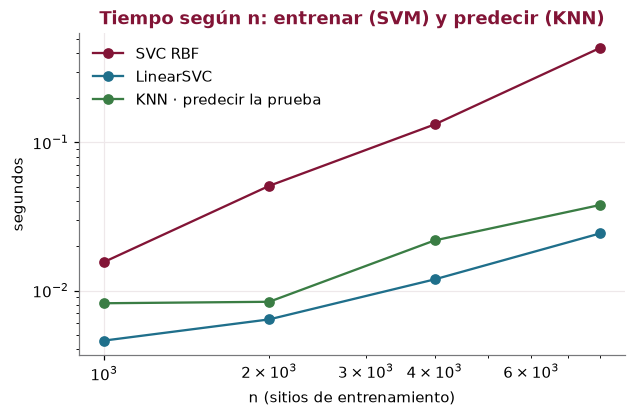

SVC RBF: ×28 de tiempo al multiplicar n por 8 · LinearSVC: ×5.3 · KNN (predecir 2764 sitios): ×4.6


,SVC RBF,LinearSVC,KNN · predecir la prueba
n,,,
1000,0.016,0.005,0.008
2000,0.051,0.006,0.008
4000,0.132,0.012,0.022
8000,0.435,0.024,0.038


In [18]:
from sklearn.svm import LinearSVC

tiempos = []
for n in (1000, 2000, 4000, 8000):
    Xn, yn = Xp_tr.iloc[:n], yp_tr.iloc[:n]
    fila = {"n": n}
    for nombre, mod in (("SVC RBF", SVC(C=3, gamma=0.03)), ("LinearSVC", LinearSVC(C=1))):
        pipe = make_pipeline(StandardScaler(), mod)
        t0 = time.perf_counter()
        pipe.fit(Xn, yn)
        fila[nombre] = time.perf_counter() - t0
    knn_n = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)).fit(Xn, yn)
    t0 = time.perf_counter()
    knn_n.predict(Xp_te)
    fila["KNN · predecir la prueba"] = time.perf_counter() - t0
    tiempos.append(fila)
tabla_t = pd.DataFrame(tiempos).set_index("n")
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for col, color in zip(tabla_t.columns, (UEES["vino"], UEES["azul"], UEES["verde"])):
    ax.plot(tabla_t.index, tabla_t[col], "o-", color=color, label=col)
ax.set(xscale="log", yscale="log", title="Tiempo según n: entrenar (SVM) y predecir (KNN)", xlabel="n (sitios de entrenamiento)", ylabel="segundos")
ax.legend()
plt.show()
crec = (tabla_t["SVC RBF"].iloc[-1] / tabla_t["SVC RBF"].iloc[0])
crec_knn = tabla_t["KNN · predecir la prueba"].iloc[-1] / tabla_t["KNN · predecir la prueba"].iloc[0]
print(f"SVC RBF: ×{crec:.0f} de tiempo al multiplicar n por 8 · LinearSVC: ×{tabla_t['LinearSVC'].iloc[-1] / tabla_t['LinearSVC'].iloc[0]:.1f} · KNN (predecir {len(Xp_te)} sitios): ×{crec_knn:.1f}")
tabla_t.round(3)

**Qué observar.** Al multiplicar n por 8, el tiempo de la SVM con kernel crece mucho más que 8 veces, mientras que `LinearSVC` apenas se mueve. Con cientos de miles de filas, la SVM con kernel deja de ser práctica: se usa `LinearSVC`, aproximaciones del kernel (`Nystroem`) o modelos de árboles. KNN se comporta al revés: casi no hay entrenamiento que medir, pero el tiempo de **predecir** la prueba crece con n, porque cada predicción calcula una distancia a cada sitio guardado (con n pequeño domina un costo fijo). Con millones de filas y predicción en línea, KNN necesita índices de vecinos aproximados o se reemplaza por otro modelo.

> **Respuesta de referencia**

**Reflexión · escalado.** Las SVM con kernel RBF y KNN dependen de distancias: sin `StandardScaler`, una variable con escala mayor domina $\|x - x'\|$ (γ pierde sentido y los vecinos dejan de ser parecidos). En este dataset los indicadores ya están en {−1, 0, 1}, así que el efecto es menor, pero el escalador dentro del pipeline es la práctica correcta y no cuesta nada.

**Reflexión · millones de URL por día.** Ni la SVM con kernel (entrenamiento caro y miles de vectores de soporte) ni KNN (cada predicción recorre todo el entrenamiento y hay que guardarlo entero) escalan bien. Lo razonable es un modelo lineal o de árboles potenciados, o un índice de vecinos aproximados si la semejanza con casos conocidos es clave.

## Autoverificación

In [19]:
assert coseno > 0.99
assert malla.max() > 0.9, "Con el kernel RBF adecuado, la exactitud en lunas debería superar 0.9."
assert tabla_phish.loc["SVC RBF (mejor malla)", "F1 prueba"] > tabla_phish.loc["logística (baseline)", "F1 prueba"], "La SVM RBF debería superar al baseline."
assert tabla_t["SVC RBF"].iloc[-1] > tabla_t["LinearSVC"].iloc[-1], "Con n grande, LinearSVC debería ser más rápido."
assert coinciden == 1.0, "Tu KNN debe coincidir con scikit-learn."
assert 1 < k_mejor < 151, "El mejor k no debería estar en un extremo de la malla."
assert acc_unidad_escalada > acc_unidad_sin + 0.05, "Escalar debería recuperar la exactitud que se pierde al cambiar la unidad."
print("✓ E2.3 completo")

✓ E2.3 completo


## Lista de cotejo (autoevaluación)

- [ ] Tu SVM por subgradiente apunta en la misma dirección que la de scikit-learn.
- [ ] Identificaste los vectores de soporte y el ancho del margen.
- [ ] Comparaste kernel lineal y RBF, y leíste la malla C × gamma.
- [ ] Buscaste C y γ sin tocar la prueba en el caso de phishing.
- [ ] Mediste cómo crece el tiempo de entrenamiento con n.
- [ ] Programaste KNN desde cero y coincide con `KNeighborsClassifier`.
- [ ] Elegiste k por validación cruzada y comprobaste el efecto de escalar y de los pesos 1/d.
- [ ] Comparaste KNN con la SVM en phishing, incluido el tiempo de predicción.

**Reflexión:** en un sistema que clasifica millones de URL por día, ¿usarías una SVM con kernel o KNN? ¿Qué alternativa propondrías?

**Cómo te prepara para la Tarea 2:** la SVM es uno de los cinco modelos que compararás, con búsqueda de C y gamma dentro de la validación. KNN no es obligatorio en la tarea, pero es un buen modelo de referencia adicional.

## Desafío opcional con IA agéntica · Escalar la SVM y KNN a millones de datos

**Objetivo.** Comparar alternativas más baratas que la SVM con kernel y que KNN cuando los datos crecen.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
En el notebook resuelto E2.3 (SVM, kernels y KNN con PhishingWebsites), agrega una sección que compare, con el mismo entrenamiento y la misma prueba, un SVC RBF, un pipeline con Nystroem y LinearSVC, y KNN. Mide F1, tiempo de entrenamiento y tiempo de predicción al crecer n de 1000 a 8000, buscando los hiperparámetros solo con el entrenamiento. Explica en español qué modelo usarías para clasificar millones de URL por día y por qué.
```

**Cómo verificar el resultado**

- Todos los modelos usan las mismas particiones.
- Gamma, C y k se buscan sin tocar la prueba.
- La recomendación pesa desempeño, costo de entrenar y costo de predecir.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.